In [18]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Sliding window and bootstrap parameters
window_size = 1_000  # Number of variants in the sliding window
step_size = 1_0      # Step between sampled points (controls plot smoothness)
n_boot = 1000         # Number of bootstrap resamples across regions
max_num_variants = 500_000  # Maximum number of top-ranked variants per annotation (None = no limit)


# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/variant_class.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']
selected_categories = vc['tool_categories']
x_label = vc['x_label']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Categories: {selected_categories}")
print(f"  X-label: {x_label}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: missense
  Filters: ["pl.col('consequence_missense_variant') == True"]
  Categories: ['missense']
  X-label: Top N missense variants
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""clinpred_score""","""#FFFF00""","""ClinPred""",1
"""missense""","""bayes_del""","""#FFDC80""","""BayesDel""",1
"""missense""","""polyphen""","""#FFA000""","""PolyPhen2""",1
"""missense""","""revel_score""","""#FF7000""","""REVEL""",1
"""missense""","""am_pathogenicity""","""#E63946""","""AlphaMissense""",1
…,…,…,…,…
"""regulatory""","""fz_all_mean""","""#1f77b4""","""Flashzoi mean across RNA (all)""",1
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#FFA500""","""Flashzoi min across RNA (all)""",-1


In [20]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [21]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_avg_ukbbgym.parquet"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_0_ukbbgym.parquet"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .with_columns(
        fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_all_max = pl.max_horizontal(cs.starts_with('RNA:')),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_all_max', 'fz_all_mean'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_128799/2215979549.py:18: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_all_max,fz_all_mean
str,str,f32,f32,f32
"""chr22:24594263:T:G""","""ENSG00000100031""",-0.008994,0.001747,0.003926
"""chr14:59368918:C:T""","""ENSG00000100592""",-0.033651,0.004826,0.004763
"""chr17:50205580:T:C""","""ENSG00000108821""",-0.038777,0.027446,0.003392
"""chr5:76418836:T:C""","""ENSG00000145703""",-0.000617,0.001371,0.000237
"""chr14:59213667:G:T""","""ENSG00000100592""",-0.002696,0.003707,0.000671
…,…,…,…,…
"""chr4:88012364:C:G""","""ENSG00000118762""",-0.002406,0.004344,0.000717
"""chr7:153910910:T:C""","""ENSG00000130226""",-0.004095,0.00267,0.00088
"""chr19:17111312:C:T""","""ENSG00000099331""",-0.002071,0.00233,0.000114


In [22]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
_dynamic_filters = [eval(f) for f in vc_filters]
if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
)

# selected_categories is already set from YAML in the config cell

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_128799/2680855078.py:52: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_128799/2680855078.py:61: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,esmscoremissense,clinpred_score,am_pathogenicity,bayes_del,polyphen,esm1b_llr,cpt1_llr,revel_score,id
str,f32,f32,f32,f32,f32,f32,f32,f32,str
"""ENSG00000167165""",-3.898,0.760216,0.1121,-0.471487,0.176,0.0,0.0,0.178,"""chr2:233693641:C:T"""
"""ENSG00000157106""",-4.693,0.959947,0.1855,-0.15503,0.928,-4.629,0.124054,0.277,"""chr16:18836087:G:A"""
"""ENSG00000077044""",-4.484,0.458646,0.216,-0.237068,0.007,-8.595,0.393211,0.158,"""chr2:233434480:T:C"""
"""ENSG00000008710""",-3.622,0.041596,0.0983,-0.299502,0.023,-4.904,0.058442,0.124,"""chr16:2106520:T:C"""
"""ENSG00000008710""",-4.549,0.991422,0.3193,-0.144272,0.99,-12.345,0.207345,0.523,"""chr16:2092536:T:A"""
…,…,…,…,…,…,…,…,…,…
"""ENSG00000166603""",-6.801,0.575126,0.249,-0.325075,0.421,-9.831,0.249894,0.232,"""chr18:60371632:T:C"""
"""ENSG00000138829""",-9.834,0.992285,0.3533,0.447846,0.874,-15.468,0.38861,0.867,"""chr5:128335224:G:A"""
"""ENSG00000188064""",-11.406,0.989861,0.3082,0.275746,0.448,-14.564,0.559823,0.805,"""chr22:45922872:A:C"""


In [23]:
# Difference aftter dropping all ClinVar annotated variants
405_054 - 313_816

91238

In [24]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_128799/2928459309.py:27: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i32
"""chr4:17877437:T:C""","""ENSG00000178177""","""clinpred_score""",1
"""chr6:165662043:C:G""","""ENSG00000112541""","""clinpred_score""",1
"""chr2:178654244:C:T""","""ENSG00000155657""","""clinpred_score""",1
"""chr4:2536947:A:C""","""ENSG00000125386""","""clinpred_score""",1
"""chr3:97875504:A:T""","""ENSG00000080200""","""clinpred_score""",1


In [25]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_128799/1598827054.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr16:2099762:T:C""","""ENSG00000008710""","""am_pathogenicity""",0.0568,"""missense""",1,329222.0
"""chr16:88734779:C:T""","""ENSG00000103335""","""am_pathogenicity""",0.2969,"""missense""",1,128569.0
"""chr11:93788112:A:T""","""ENSG00000042429""","""am_pathogenicity""",0.634,"""missense""",1,74749.0
"""chr14:67806556:C:T""","""ENSG00000072121""","""am_pathogenicity""",0.7151,"""missense""",1,64713.0
"""chr7:5313671:G:A""","""ENSG00000182095""","""am_pathogenicity""",0.0851,"""missense""",1,272474.0
…,…,…,…,…,…,…
"""chr1:176699232:C:T""","""ENSG00000116183""","""am_pathogenicity""",0.2057,"""missense""",1,158207.0
"""chr17:35822718:T:G""","""ENSG00000270647""","""am_pathogenicity""",0.1252,"""missense""",1,211230.0
"""chr16:28903419:G:A""","""ENSG00000196296""","""am_pathogenicity""",0.0677,"""missense""",1,313454.0


In [26]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""esmscoremissense""",380133
"""bayes_del""",376608
"""clinpred_score""",374599
"""revel_score""",362940
"""polyphen""",344747
"""am_pathogenicity""",333489
"""esm1b_llr""",325975
"""cpt1_llr""",316538


In [27]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [28]:
pheno_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr2:178571014:C:T""","""leg_fatfree_mass_left_int""",-0.04929,7
"""chr17:50187944:C:T""","""basal_metabolic_rate_int""",0.992802,3
"""chr2:178741274:T:C""","""seated_height_int""",0.461834,9
"""chr15:58893289:C:A""","""arm_fat_mass_right_int""",0.632569,1
"""chr2:203125973:G:C""","""seated_height_int""",0.39507,12


## Average z-score by annotation rank (sliding window)

In [30]:
# --- Re-ranking bootstrap: join variant z-scores with annotation ranks ---
id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with gene_trait_df
# Direction-correct mean_pheno_value: if loftee_corr_dir == -1, flip the z-score
# so that "deleterious" variants always have positive z-scores
variant_zscores = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

# Join z-scores with annotation ranks, sort by rank (most deleterious first)
ranked_zscores = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
        on=['id', 'region'],
        how='inner'
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(
        row_pos = pl.col('annotation').cum_count().over('annotation'),
    )
    .pipe(lambda df: df.filter(pl.col('row_pos') <= max_num_variants) if max_num_variants is not None else df)
    .collect(engine='streaming')
)

# Map regions to integer indices for fast bootstrap resampling
all_regions = sorted(gene_trait_df['region'].unique().to_list())
n_regions = len(all_regions)
region_idx_map = pl.DataFrame({'region': all_regions, '_region_idx': np.arange(n_regions, dtype=np.int32)})
ranked_zscores = ranked_zscores.join(region_idx_map, on='region', how='left')

annotations_list = sorted(ranked_zscores['annotation'].unique().to_list())


# --- Helper functions ---

def sliding_window_means_unweighted(zscores, bin_ends, window_size):
    """Standard prefix-sum sliding window mean (for point estimates)."""
    csum = np.empty(len(zscores) + 1, dtype=np.float64)
    csum[0] = 0.0
    np.cumsum(zscores, out=csum[1:])
    return (csum[bin_ends] - csum[bin_ends - window_size]) / window_size


def expanded_csum_at(positions, cw, cwz, z, N):
    """Compute the prefix sum of the virtual expanded array at given positions.
    
    The "expanded array" is the conceptual array where variant i is repeated
    w[i] times (its gene's bootstrap weight). Instead of materializing this
    array (which changes every iteration), we compute its prefix sum
    analytically using binary search into the cumulative weight array.
    
    For expanded position e, we find the original variant k whose copies
    span that position, then:
        expanded_csum[e] = cwz[k-1] + z[k-1] * (e - cw[k-1])
    
    This is the full weighted prefix sum up to variant k-2, plus a partial
    contribution from variant k-1 for the copies that fall within [1, e].
    
    Parameters
    ----------
    positions : int array — positions in the expanded (virtual) array
    cw  : float array (N+1,) — cumulative variant weights, cw[0]=0
    cwz : float array (N+1,) — cumulative (z * weight), cwz[0]=0
    z   : float array (N,)   — z-scores in original sort order
    N   : int — number of original variants
    """
    k = np.searchsorted(cw, positions, side='left')
    k_safe = np.clip(k, 1, N)
    result = cwz[k_safe - 1] + z[k_safe - 1] * (positions - cw[k_safe - 1])
    result = np.where(positions <= 0, 0.0, result)
    return result


def sliding_window_reranked(z, cw, cwz, N, total_expanded, bin_ends, window_size):
    """Sliding window mean on the virtual expanded (re-ranked) array.
    
    Returns an array of means at each bin_end position.
    Positions beyond the expanded array length are NaN.
    """
    valid_mask = bin_ends <= total_expanded
    valid_bins = bin_ends[valid_mask]
    means = np.full(len(bin_ends), np.nan, dtype=np.float64)
    if len(valid_bins) == 0:
        return means

    right = expanded_csum_at(valid_bins, cw, cwz, z, N)
    left = expanded_csum_at(valid_bins - window_size, cw, cwz, z, N)
    means[valid_mask] = (right - left) / window_size
    return means


# --- Prepare per-annotation sorted arrays and bin endpoints ---
anno_arrays = {}
for annotation in tqdm(annotations_list, desc='Preparing arrays'):
    adf = ranked_zscores.filter(pl.col('annotation') == annotation)
    z = adf['mean_pheno_value'].to_numpy().astype(np.float64)
    r_idx = adf['_region_idx'].to_numpy()
    N = len(z)

    # bin_ends defined on the full (unbootstrapped) data
    bin_ends = np.arange(window_size, N + 1, step_size, dtype=np.int64)

    anno_arrays[annotation] = {
        'zscores': z,
        'region_idx': r_idx,
        'bin_ends': bin_ends,
        'N': N,
    }

# --- Point estimates (unweighted, on full data) ---
point_means = {}
for annotation in annotations_list:
    d = anno_arrays[annotation]
    point_means[annotation] = sliding_window_means_unweighted(
        d['zscores'], d['bin_ends'], window_size
    )

# --- Re-ranking bootstrap CIs across regions ---
rng = np.random.default_rng(42)
boot_means = {ann: np.full((n_boot, len(anno_arrays[ann]['bin_ends'])), np.nan)
              for ann in annotations_list}

# Pre-allocate buffers to avoid repeated memory allocation in the hot loop
max_N = max(d['N'] for d in anno_arrays.values())
cw_buf = np.empty(max_N + 1, dtype=np.float64)
cwz_buf = np.empty(max_N + 1, dtype=np.float64)

for b in tqdm(range(n_boot), desc='Re-ranking bootstrap'):
    idx = rng.choice(n_regions, size=n_regions, replace=True)
    region_weights = np.bincount(idx, minlength=n_regions).astype(np.float64)

    for annotation in annotations_list:
        d = anno_arrays[annotation]
        N = d['N']
        z = d['zscores']
        vw = region_weights[d['region_idx']]

        # Build cumulative weight and cumulative weighted-z using pre-allocated buffers
        cw = cw_buf[:N + 1]
        cw[0] = 0.0
        np.cumsum(vw, out=cw[1:])

        cwz = cwz_buf[:N + 1]
        cwz[0] = 0.0
        np.cumsum(z * vw, out=cwz[1:])

        total_expanded = int(cw[N])

        boot_means[annotation][b] = sliding_window_reranked(
            z, cw, cwz, N, total_expanded, d['bin_ends'], window_size
        )

# --- Build output DataFrame with percentile-based CIs ---
all_results = []
for annotation in annotations_list:
    d = anno_arrays[annotation]
    bm = boot_means[annotation]

    se = np.nanstd(bm, axis=0).astype(np.float32)

    all_results.append(pl.DataFrame({
        'annotation': annotation,
        'bin_end': d['bin_ends'].astype(np.float64),
        'mean_zscore': point_means[annotation].astype(np.float32),
        'ci_lower': np.nanpercentile(bm, 2.5, axis=0).astype(np.float32),
        'ci_upper': np.nanpercentile(bm, 97.5, axis=0).astype(np.float32),
        # 'se_zscore': se,
        # 'ci_lower': (pm - 1.96 * se).astype(np.float32),
        # 'ci_upper': (pm + 1.96 * se).astype(np.float32),
    }))

zscore_binned = pl.concat(all_results).sort(['annotation', 'bin_end'])

print(f"Sliding window results: {zscore_binned.shape[0]} points across {zscore_binned['annotation'].n_unique()} annotations")
zscore_binned

Variant z-scores: 339974 variant-gene pairs


Re-ranking bootstrap: 100%|██████████| 1000/1000 [01:05<00:00, 15.27it/s]


Sliding window results: 251071 points across 8 annotations


annotation,bin_end,mean_zscore,ci_lower,ci_upper
str,f64,f32,f32,f32
"""am_pathogenicity""",1000.0,0.299623,0.225908,0.372029
"""am_pathogenicity""",1010.0,0.297793,0.225167,0.373483
"""am_pathogenicity""",1020.0,0.293447,0.222742,0.370137
"""am_pathogenicity""",1030.0,0.288993,0.219993,0.366765
"""am_pathogenicity""",1040.0,0.285637,0.222165,0.364842
…,…,…,…,…
"""revel_score""",324580.0,-0.02079,-0.062062,0.071575
"""revel_score""",324590.0,-0.024345,-0.061802,0.069098
"""revel_score""",324600.0,-0.020738,-0.059999,0.071869


## Plotting

In [31]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_end = pl.col('bin_end').log10(),
        log_bin_end_inv = (1 / pl.col('bin_end')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_end')
)

plt_df

annotation,bin_end,mean_zscore,ci_lower,ci_upper,log_bin_end,log_bin_end_inv,color,label,category
str,f64,f32,f32,f32,f64,f64,str,str,str
"""am_pathogenicity""",1000.0,0.299623,0.225908,0.372029,3.0,-3.0,"""#E63946""","""AlphaMissense""","""missense"""
"""bayes_del""",1000.0,0.428875,0.319636,0.536977,3.0,-3.0,"""#FFDC80""","""BayesDel""","""missense"""
"""clinpred_score""",1000.0,0.378791,0.301788,0.467057,3.0,-3.0,"""#FFFF00""","""ClinPred""","""missense"""
"""cpt1_llr""",1000.0,0.501936,0.417174,0.58805,3.0,-3.0,"""#8B0000""","""CPT-1""","""missense"""
"""esm1b_llr""",1000.0,0.247964,0.182903,0.322002,3.0,-3.0,"""#CD853F""","""ESM1b""","""missense"""
…,…,…,…,…,…,…,…,…,…
"""esmscoremissense""",339840.0,-0.00749,-0.063148,0.081116,5.531274,-5.531274,"""#8B4513""","""ESM1v""","""missense"""
"""esmscoremissense""",339850.0,-0.006535,-0.060122,0.08286,5.531287,-5.531287,"""#8B4513""","""ESM1v""","""missense"""
"""esmscoremissense""",339860.0,-0.00792,-0.060067,0.081032,5.5313,-5.5313,"""#8B4513""","""ESM1v""","""missense"""


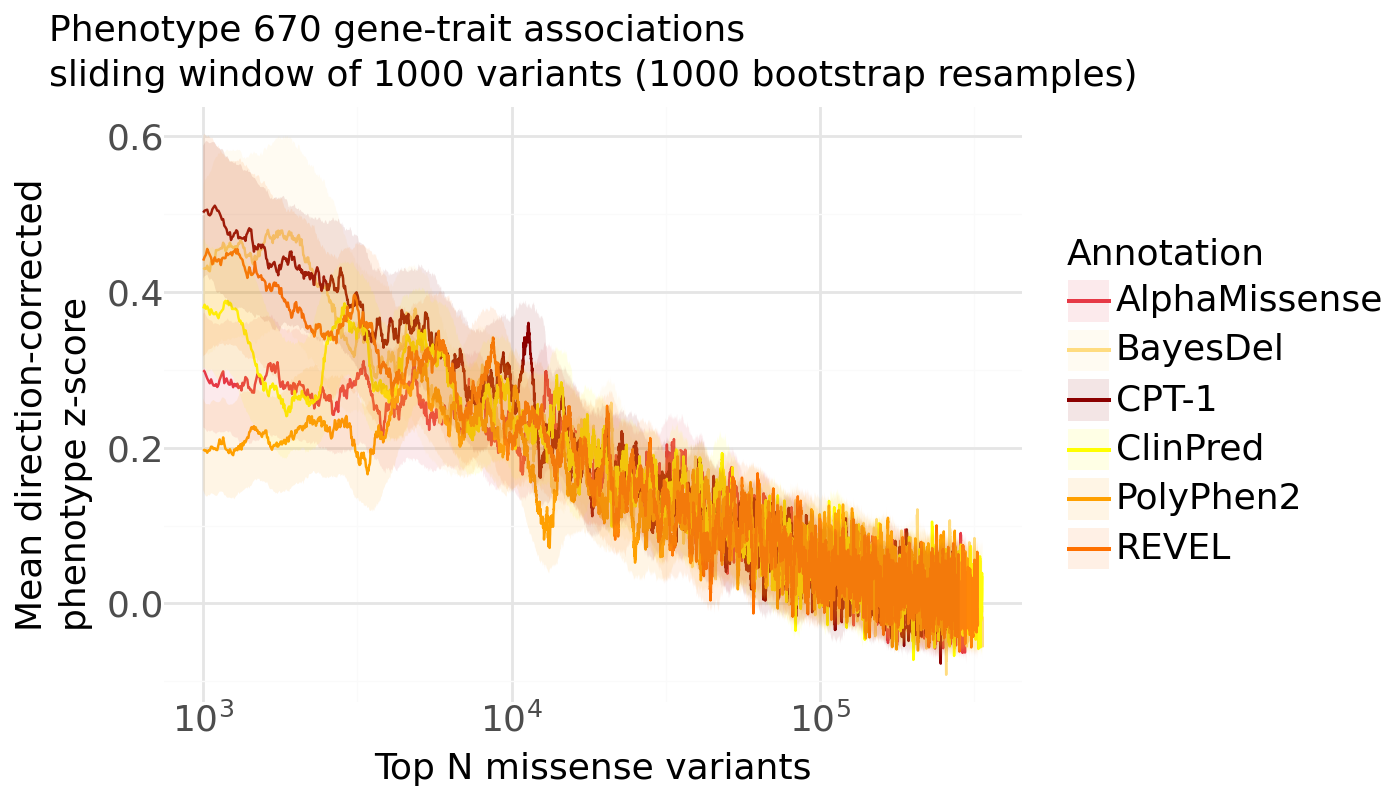

In [32]:
plot_df_small = (
    plt_df
    .filter(
        # (pl.col('bin_end') <= 10_000),
        (~pl.col('annotation').is_in(['esm1b_llr', 'esmscoremissense']))
    )
)

# Generate breaks and labels for x-axis
max_rank = zscore_binned['bin_end'].max()
min_rank = zscore_binned['bin_end'].min()
start_exp = int(np.floor(np.log10(min_rank)))
end_exp = int(np.ceil(np.log10(max_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df_small,
        aes(x='log_bin_end', y='mean_zscore')
    )
    # + loftee_point
    # + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Phenotype {gene_trait_df.shape[0]} gene-trait associations\nsliding window of {window_size} variants ({n_boot} bootstrap resamples)",
        y=f"Mean direction-corrected\nphenotype z-score",
        x=x_label,
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + theme_minimal()
    + theme(
        figure_size=(7, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        # legend_position=(0.95, 0.95),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Extended plot

In [33]:
# Include LOFTEE HC reference point in the point plot
show_loftee_point = True

# X-axis variable for plots:
# x_col = 'log_bin_end_inv' #log scale, top variants on the right
x_col = 'bin_end'

# Show compact point plot panel next to the line plot
show_point_plot = True

# LOFTEE point
loftee_vars = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .filter(pl.col('loftee_hc')==1)
    .collect(engine='streaming')
)

id_region = loftee_vars.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
loftee_zscores = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

mean_zscore = loftee_zscores['mean_pheno_value'].mean()
se_zscore = loftee_zscores['mean_pheno_value'].std() / (loftee_zscores.shape[0] ** 0.5)
ci_lower = mean_zscore - 1.96 * se_zscore
ci_upper = mean_zscore + 1.96 * se_zscore

loftee_point_df = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'bin_end': float(loftee_zscores.shape[0]),
    'log_bin_end_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
})

/tmp/ipykernel_128799/2408447359.py:16: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


/tmp/ipykernel_128799/2248299871.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


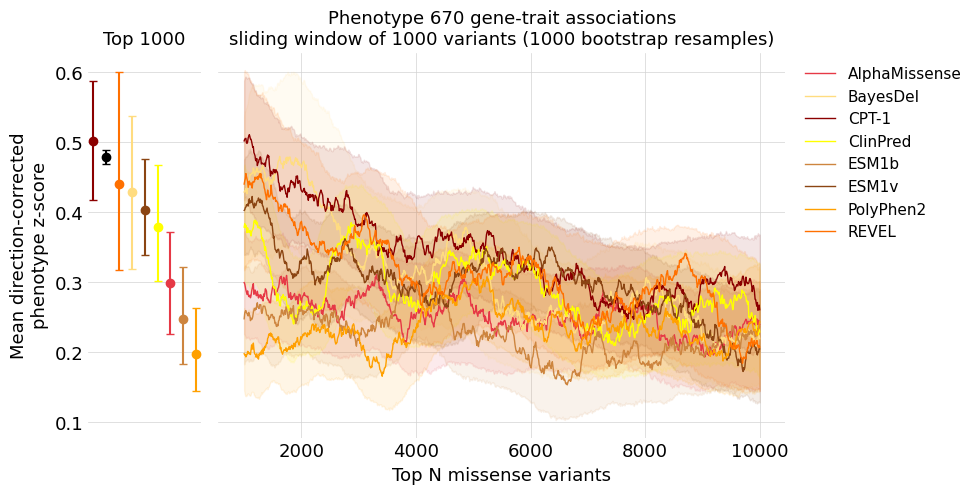

In [34]:
plot_df = (
    plt_df
    .filter(
        (pl.col('bin_end') <= 10_000),
        # (~pl.col('annotation').is_in(['esm1b_llr', 'esmscoremissense']))
    )
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))

def apply_theme_minimal(ax):
    """Apply plotnine theme_minimal style to a matplotlib axis."""
    ax.set_facecolor('white')
    ax.grid(True, which='major', color='#d3d3d3', linewidth=0.5)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

# --- Figure setup: point plot on left, line plot on right ---
if show_point_plot:
    fig, (ax_point, ax_line) = plt.subplots(
        1, 2, figsize=(9, 5), sharey=True,
        gridspec_kw={'width_ratios': [1, 5], 'wspace': 0.05}
    )
else:
    fig, ax_line = plt.subplots(figsize=(6, 4))
    ax_point = None

apply_theme_minimal(ax_line)
if ax_point is not None:
    apply_theme_minimal(ax_point)

# --- Line plot (right panel) ---
for label in sorted(plot_df['label'].unique().to_list()):
    sub = plot_df.filter(pl.col('label') == label)
    c = color_dict[label]
    x = sub[x_col].to_numpy()
    ax_line.plot(x, sub['mean_zscore'].to_numpy(), color=c, linewidth=1, label=label)
    ax_line.fill_between(x, sub['ci_lower'].to_numpy(), sub['ci_upper'].to_numpy(), color=c, alpha=0.1)

ax_line.set_xlabel(x_label, fontsize=13)
ax_line.set_title(
    f"Phenotype {gene_trait_df.shape[0]} gene-trait associations\n"
    f"sliding window of {window_size} variants ({n_boot} bootstrap resamples)",
    fontsize=13)
ax_line.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=11, framealpha=0.8, edgecolor='white')
ax_line.tick_params(labelsize=13)

if x_col == 'log_bin_end_inv':
    max_rank = zscore_binned['bin_end'].max()
    min_rank = zscore_binned['bin_end'].min()
    start_exp = int(np.floor(np.log10(1/max_rank)))
    end_exp = int(np.ceil(np.log10(1/min_rank)))
    breaks = np.arange(start_exp, end_exp + 1)
    ax_line.set_xticks(breaks)
    ax_line.set_xticklabels([f"$10^{{{int(-b)}}}$" for b in breaks])

# --- Y-axis label on the leftmost panel ---
if ax_point is not None:
    ax_point.set_ylabel("Mean direction-corrected\nphenotype z-score", fontsize=13)
    ax_line.tick_params(labelleft=False)
else:
    ax_line.set_ylabel("Mean direction-corrected\nphenotype z-score", fontsize=13)

# --- Point plot (left panel) ---
if ax_point is not None:
    first_bin = plot_df.filter(pl.col('bin_end') == float(window_size))

    compact_df = first_bin.select([
        'label',
        pl.col('mean_zscore').cast(pl.Float64),
        pl.col('ci_lower').cast(pl.Float64),
        pl.col('ci_upper').cast(pl.Float64),
        'color',
    ])

    if show_loftee_point:
        loftee_row = pl.DataFrame({
            'label': ['LOFTEE HC'],
            'mean_zscore': [float(loftee_point_df['mean_zscore'][0])],
            'ci_lower': [float(loftee_point_df['ci_lower'][0])],
            'ci_upper': [float(loftee_point_df['ci_upper'][0])],
            'color': ['black'],
        })
        compact_df = pl.concat([compact_df, loftee_row])

    compact_df = compact_df.sort('mean_zscore', descending=True)

    for i, row in enumerate(compact_df.iter_rows(named=True)):
        ax_point.errorbar(
            i, row['mean_zscore'],
            yerr=[[row['mean_zscore'] - row['ci_lower']],
                  [row['ci_upper'] - row['mean_zscore']]],
            fmt='o', color=row['color'], capsize=3, markersize=6,
        )

    # ax_point.axhline(0, linestyle=':', color='grey', linewidth=0.8)
    ax_point.set_xticks([])
    ax_point.set_xlabel("")
    ax_point.set_title(f"Top {window_size}", fontsize=13)
    ax_point.tick_params(labelsize=13)

# --- Compute tight y-limits from all plotted data ---
all_y_vals = []
for label in plot_df['label'].unique().to_list():
    sub = plot_df.filter(pl.col('label') == label)
    all_y_vals.extend(sub['ci_lower'].to_list())
    all_y_vals.extend(sub['ci_upper'].to_list())
if ax_point is not None and 'compact_df' in dir():
    all_y_vals.extend(compact_df['ci_lower'].to_list())
    all_y_vals.extend(compact_df['ci_upper'].to_list())
y_min, y_max = min(all_y_vals), max(all_y_vals)
y_pad = (y_max - y_min) * 0.05
ax_line.set_ylim(y_min - y_pad, y_max + y_pad)

fig.patch.set_facecolor('white')
fig.tight_layout()
fig.subplots_adjust(wspace=0.05)
plt.show()
plt.close(fig)